<a href="https://colab.research.google.com/github/Gu1-Fr4nc0/-Simulador_de_Sistemas_Operacionais/blob/main/pesquisa_ENIAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Clona o seu repositório para dentro do Colab
!git clone https://github.com/Gu1-Fr4nc0/brazilian-coffee-scene-dataset-experiments.git

# 2. Mostra uma lista de todas as pastas e arquivos que tem lá dentro
!ls -R brazilian-coffee-scene-dataset-experiments

Cloning into 'brazilian-coffee-scene-dataset-experiments'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 86 (delta 25), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 2.43 MiB | 5.23 MiB/s, done.
Resolving deltas: 100% (25/25), done.
brazilian-coffee-scene-dataset-experiments:
data  README.md  results  script

brazilian-coffee-scene-dataset-experiments/data:
coffee_meta_features.csv

brazilian-coffee-scene-dataset-experiments/results:
comparativo_barras.png	 performances_cnn.csv	  performances_ml.csv
comparativo_boxplot.png  performances_hybrid.csv  performances_vgg16.csv

brazilian-coffee-scene-dataset-experiments/script:
01_generate_datasets.py  05_running_hybrid_VGG.py  07_traditional_ML.py
04_running_pure_VGG.py	 06_running_CNN.py	   08_statistical_test.py


In [2]:
!cat brazilian-coffee-scene-dataset-experiments/script/05_running_hybrid_VGG.py

import os 
import pandas as pd
import numpy as np
import keras
from PIL import Image
from tensorflow.keras.layers import Input, Dense, Concatenate, Flatten, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

def get_hybrid_model(input_shape_img, input_shape_features):
    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape_img)
    vgg_base.trainable = False 
    
    img_input = Input(shape=input_shape_img)
    x_img = vgg_base(img_input)
    x_img = Flatten()(x_img)
    
    feat_input = Input(shape=(input_shape_features,))
    x_feat = BatchNormalization()(feat_input)
    x_feat = Dense(64, activation='relu')(x_feat)
    
    combined = Concatenate()([x_img, x_feat])
    z = Dense(128, activation='relu')(combined)
    output = Dense(1, activation='sigmoid')(z)
    
 

In [3]:
!pip install tensorflow

Extraindo os rótulos originais do arquivo de predições...
Lendo imagens e cruzando com o gabarito oficial (Aguarde)...
Dataset montado! Total de imagens válidas: 2875
Treinando a Rede Híbrida...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Gerando a Matriz de Confusão...


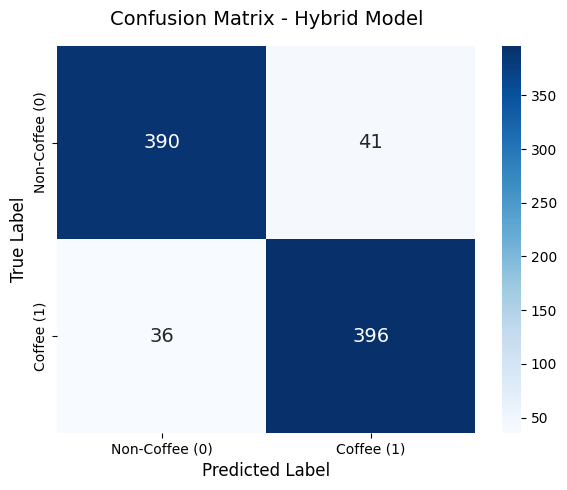

BAC final: 0.9108


In [6]:
import os
import zipfile
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from PIL import Image
import keras
from tensorflow.keras.layers import Input, Dense, Concatenate, Flatten, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.losses import BinaryCrossentropy

# --- 1. PREPARANDO O GABARITO ---
print("Extraindo os rótulos originais do arquivo de predições...")
df_pred = pd.read_csv('/content/brazilian-coffee-scene-dataset-experiments/results/predictions_dataset_1.csv')
# Extrai apenas o nome do arquivo do caminho completo
df_pred['Name_file'] = df_pred['im_path'].apply(lambda x: os.path.basename(x))
# Cria um dicionário mapeando 'nome_da_imagem.jpg' -> Rótulo Verdadeiro (0 ou 1)
gabarito = df_pred.drop_duplicates('Name_file').set_index('Name_file')['Y'].to_dict()

# Baixa as features do GitHub
csv_url = 'https://raw.githubusercontent.com/Gu1-Fr4nc0/brazilian-coffee-scene-dataset-experiments/main/data/coffee_meta_features.csv'
csv_path = '/content/coffee_meta_features.csv'
if not os.path.exists(csv_path):
    urllib.request.urlretrieve(csv_url, csv_path)
df_feat = pd.read_csv(csv_path)

# --- 2. DESCOMPACTANDO O ZIP ---
zip_path = '/content/brazilian_coffee_dataset.zip'
extract_folder = '/content/dataset_imagens'
if os.path.exists(zip_path) and not os.path.exists(extract_folder):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

# --- 3. CONSTRUINDO O DATASET COM O GABARITO EXATO ---
print("Lendo imagens e cruzando com o gabarito oficial (Aguarde)...")
images, feats, labels = [], [], []

for root, dirs, files in os.walk(extract_folder):
    for filename in files:
        if filename.endswith(('.jpg', '.jpeg', '.png', '.tif')):
            # Busca a classe verdadeira no dicionário que criamos
            label = gabarito.get(filename)

            if label is not None:
                feat_row = df_feat[df_feat['Name_file'] == filename]
                if not feat_row.empty:
                    img_path = os.path.join(root, filename)
                    img = np.array(Image.open(img_path).resize((64, 64))) / 255.0

                    images.append(img)
                    feats.append(feat_row.drop(columns=['Name_file']).values[0])
                    labels.append(label)

X_img = np.array(images)
X_feat = np.nan_to_num(np.array(feats), nan=0.0)
y = np.array(labels)

print(f"Dataset montado! Total de imagens válidas: {len(X_img)}")

# --- 4. DIVISÃO TREINO/TESTE (Seed 29) ---
X_train_img, X_test_img, X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    X_img, X_feat, y, test_size=0.3, random_state=29, stratify=y
)

# --- 5. TREINAMENTO (1 a 2 min com GPU) ---
print("Treinando a Rede Híbrida...")
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))
vgg_base.trainable = False

img_input = Input(shape=(64,64,3))
x_img = vgg_base(img_input)
x_img = Flatten()(x_img)

feat_input = Input(shape=(X_train_feat.shape[1],))
x_feat = BatchNormalization()(feat_input)
x_feat = Dense(64, activation='relu')(x_feat)

combined = Concatenate()([x_img, x_feat])
z = Dense(128, activation='relu')(combined)
output = Dense(1, activation='sigmoid')(z)

model = Model(inputs=[img_input, feat_input], outputs=output)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss=BinaryCrossentropy(), metrics=['accuracy'])

model.fit([X_train_img, X_train_feat], y_train, epochs=25, batch_size=16, verbose=0)

# --- 6. PLOTAGEM DA MATRIZ ---
print("Gerando a Matriz de Confusão...")
prob_hibrido = model.predict([X_test_img, X_test_feat], verbose=0)
y_pred = np.round(prob_hibrido).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Coffee (0)', 'Coffee (1)'],
            yticklabels=['Non-Coffee (0)', 'Coffee (1)'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix - Hybrid Model', fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

bac_final = balanced_accuracy_score(y_test, y_pred)
print(f"BAC final: {bac_final:.4f}")

In [7]:
import pandas as pd

# Lê o arquivo de predições
df_pred = pd.read_csv('/content/predictions_dataset_1.csv')

# Imprime as colunas e as 5 primeiras linhas para vermos o que tem dentro
print(df_pred.columns.tolist())
display(df_pred.head())

['im_path', 'Y', 'predictions', 'algo', 'Seed']


,im_path,Y,predictions,algo,Seed
0,../dataset-brazilian_coffee_scenes/images/mont...,0,1,KNN,0
1,../dataset-brazilian_coffee_scenes/images/mont...,1,1,KNN,0
2,../dataset-brazilian_coffee_scenes/images/guax...,0,0,KNN,0
3,../dataset-brazilian_coffee_scenes/images/arce...,1,0,KNN,0
4,../dataset-brazilian_coffee_scenes/images/guar...,0,1,KNN,0


A ler as imagens para a VGG16 Pura...
A treinar a VGG16 Pura (Aguarde breves momentos)...
A gerar a Matriz de Confusão...


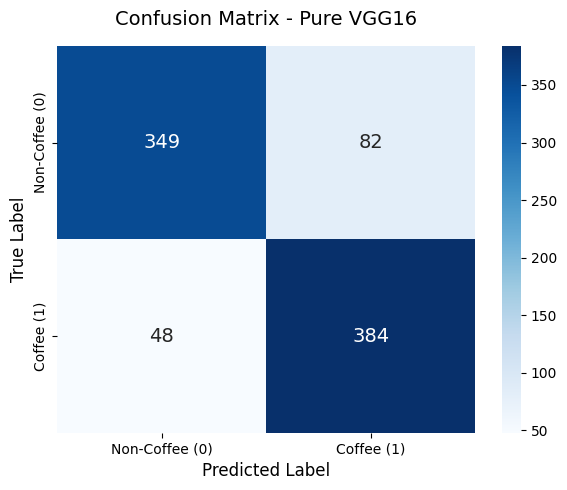

BAC VGG16 Pura: 0.8493


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from PIL import Image
import keras
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.losses import BinaryCrossentropy

# --- 1. PREPARANDO O GABARITO ---
# Assumimos que o predictions_dataset_1.csv e as imagens já estão no ambiente
df_pred = pd.read_csv('/content/predictions_dataset_1.csv')
df_pred['Name_file'] = df_pred['im_path'].apply(lambda x: os.path.basename(x))
gabarito = df_pred.drop_duplicates('Name_file').set_index('Name_file')['Y'].to_dict()

extract_folder = '/content/dataset_imagens'

# --- 2. LENDO APENAS AS IMAGENS (Sem Meta-features) ---
print("A ler as imagens para a VGG16 Pura...")
images, labels = [], []

for root, dirs, files in os.walk(extract_folder):
    for filename in files:
        if filename.endswith(('.jpg', '.jpeg', '.png', '.tif')):
            label = gabarito.get(filename)
            if label is not None:
                img_path = os.path.join(root, filename)
                # O mesmo redimensionamento exigido pela rede
                img = np.array(Image.open(img_path).resize((64, 64))) / 255.0
                images.append(img)
                labels.append(label)

X_img = np.array(images)
y = np.array(labels)

# --- 3. DIVISÃO TREINO/TESTE (A MESMA SEED 29) ---
# Isto garante que estamos a testar exatamente nas mesmas 863 imagens!
X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_img, y, test_size=0.3, random_state=29, stratify=y
)

# --- 4. ARQUITETURA VGG16 PURA ---
print("A treinar a VGG16 Pura (Aguarde breves momentos)...")
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))
vgg_base.trainable = False

img_input = Input(shape=(64,64,3))
x = vgg_base(img_input)
x = Flatten()(x)
# Uma camada densa simples, sem a concatenação do modelo híbrido
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_vgg = Model(inputs=img_input, outputs=output)
model_vgg.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss=BinaryCrossentropy(), metrics=['accuracy'])

model_vgg.fit(X_train_img, y_train, epochs=25, batch_size=16, verbose=0)

# --- 5. PLOTAGEM DA MATRIZ DE CONFUSÃO ---
print("A gerar a Matriz de Confusão...")
prob_vgg = model_vgg.predict(X_test_img, verbose=0)
y_pred_vgg = np.round(prob_vgg).astype(int)

cm_vgg = confusion_matrix(y_test, y_pred_vgg)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Coffee (0)', 'Coffee (1)'],
            yticklabels=['Non-Coffee (0)', 'Coffee (1)'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix - Pure VGG16', fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

bac_vgg = balanced_accuracy_score(y_test, y_pred_vgg)
print(f"BAC VGG16 Pura: {bac_vgg:.4f}")

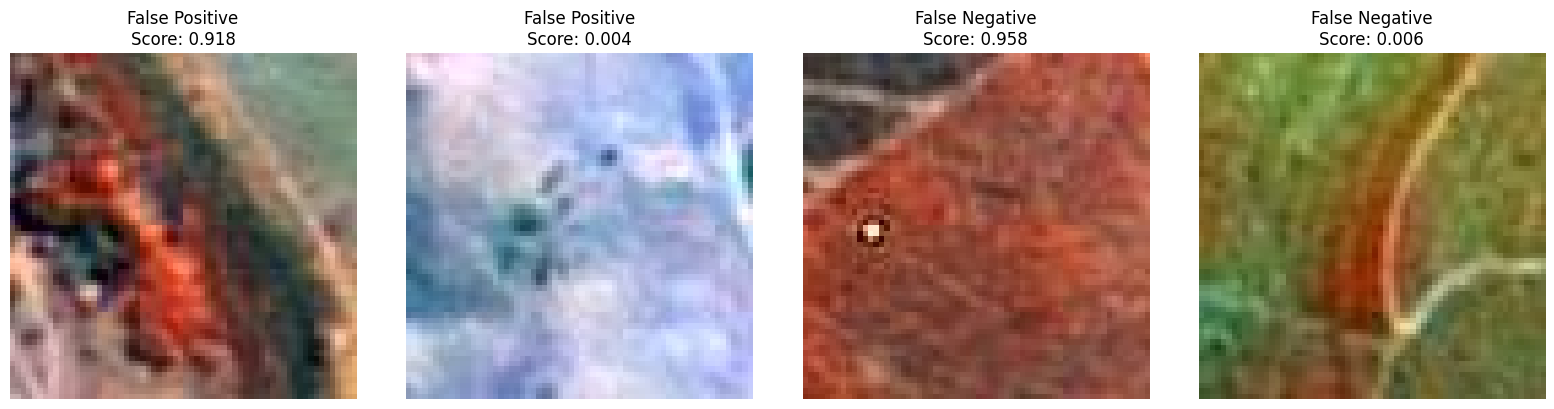

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Ajustando as variáveis para os nomes existentes no seu notebook:
# y_true -> y_test
# X_test -> X_test_img
# scores -> prob_hibrido (calculado na célula anterior)

# 1. Encontrar os índices exatos dos erros
# Falso Positivo: O modelo previu 1, mas o real era 0
# y_pred costuma ter shape (N, 1), por isso o flatten()
fp_indices = np.where((y_pred.flatten() == 1) & (y_test == 0))[0]

# Falso Negativo: O modelo previu 0, mas o real era 1
fn_indices = np.where((y_pred.flatten() == 0) & (y_test == 1))[0]

# 2. Selecionar aleatoriamente 2 imagens DISTINTAS
qtd_fp = min(2, len(fp_indices))
qtd_fn = min(2, len(fn_indices))

selected_fps = np.random.choice(fp_indices, qtd_fp, replace=False) if qtd_fp > 0 else []
selected_fns = np.random.choice(fn_indices, qtd_fn, replace=False) if qtd_fn > 0 else []

# 3. Criar a figura
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plotar os Falsos Positivos
for i in range(2):
    if i < len(selected_fps):
        idx = selected_fps[i]
        axes[i].imshow(X_test_img[idx])
        axes[i].set_title(f"False Positive\nScore: {prob_hibrido[idx][0]:.3f}", fontsize=12)
    else:
        axes[i].text(0.5, 0.5, 'No FP\nfound', ha='center', va='center')
    axes[i].axis('off')

# Plotar os Falsos Negativos
for i in range(2):
    if i < len(selected_fns):
        idx = selected_fns[i]
        axes[i+2].imshow(X_test_img[idx])
        axes[i+2].set_title(f"False Negative\nScore: {prob_hibrido[idx][0]:.3f}", fontsize=12)
    else:
        axes[i+2].text(0.5, 0.5, 'No FN\nfound', ha='center', va='center')
    axes[i+2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

# Função para extrair pixels achatados + NDVI
def preparar_baseline_pixels(imagens_array):
    # As imagens possuem 3 canais: G (índice 0), R (índice 1), NIR (índice 2)
    R = imagens_array[:, :, :, 1]
    NIR = imagens_array[:, :, :, 2]

    # Cálculo do NDVI para todos os pixels, evitando divisão por zero
    denominador = (NIR + R)
    denominador[denominador == 0] = 1e-10
    ndvi = (NIR - R) / denominador

    # Adiciona o NDVI como um "quarto canal"
    imagens_com_ndvi = np.concatenate([imagens_array, np.expand_dims(ndvi, axis=-1)], axis=-1)

    # Achata a matriz 64x64x4 para um vetor unidimensional por imagem
    return imagens_com_ndvi.reshape(imagens_com_ndvi.shape[0], -1)

print("Calculando NDVI e extraindo pixels brutos...")
X_train_baseline = preparar_baseline_pixels(X_train_img)
X_test_baseline = preparar_baseline_pixels(X_test_img)

print("Treinando o Random Forest (Baseline Pixels + NDVI)...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=29, n_jobs=-1)
rf_baseline.fit(X_train_baseline, y_train)

y_pred_baseline = rf_baseline.predict(X_test_baseline)
bac_baseline = balanced_accuracy_score(y_test, y_pred_baseline)

print(f"BAC Baseline (Pixels + NDVI): {bac_baseline:.4f}")

Calculando NDVI e extraindo pixels brutos...
Treinando o Random Forest (Baseline Pixels + NDVI)...
BAC Baseline (Pixels + NDVI): 0.8297


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.models import Model
base = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))
print("Saída conv:", base.output_shape)              # (None, 2, 2, 512)
inp = Input((64,64,3)); v = Flatten()(base(inp))
print("Após Flatten:", Model(inp, v).output_shape)   # (None, 2048)

Saída conv: (None, 2, 2, 512)
Após Flatten: (None, 2048)


In [ ]:
import pandas as pd, numpy as np
df = pd.read_csv('/content/coffee_meta_features.csv').drop(columns=['Name_file'])
print("Features brutas:", df.shape[1])
df = df.loc[:, df.nunique() > 1]                       # remove constantes
corr = df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop = [c for c in upper.columns if any(upper[c] > 0.90)]
df_sel = df.drop(columns=drop)
print("Após remover constantes + correlação>0.90:", df_sel.shape[1])
print("Mantidas:", list(df_sel.columns))

Features brutas: 97
Após remover constantes + correlação>0.90: 74
Mantidas: ['cor_RG', 'cor_RH', 'cor_RS', 'cor_RV', 'cor_GB', 'cor_GH', 'cor_GS', 'cor_GV', 'cor_GI', 'cor_BH', 'cor_BS', 'cor_BI', 'cor_HS', 'cor_HV', 'cor_SV', 'cor_SI', 'mean_H', 'std_H', 'mean_S', 'std_S', 'mean_V', 'std_V', 'std_hist_H', 'kurt_hist_H', 'std_hist_S', 'kurt_hist_S', 'std_hist_V', 'kurt_hist_V', 'std_R', 'std_G', 'std_B', 'std_hist_R', 'kurt_hist_R', 'std_hist_G', 'kurt_hist_G', 'std_hist_B', 'kurt_hist_B', 'nump_sobel', 'hu_sobel1', 'hu_sobel3', 'hu_sobel4', 'hu_sobel5', 'hu_sobel6', 'hu_sobel7', 'nump_canny', 'hu_canny1', 'hu_canny3', 'hu_canny4', 'hu_canny5', 'hu_canny6', 'hu_canny7', 'entropy_I', 'kurt_hist_I', 'skew_hist_I', 'lbp_0', 'lbp_1', 'lbp_2', 'lbp_3', 'lbp_4', 'lbp_5', 'lbp_6', 'lbp_7', 'lbp_8', 'lbp_9', 'com_inertia', 'com_energy', 'com_correlation', 'com_homogeniety', 'FFT_energy', 'FFT_entropy', 'FFT_intertia', 'FFT_homogeneity', 'SNM', 'EME']


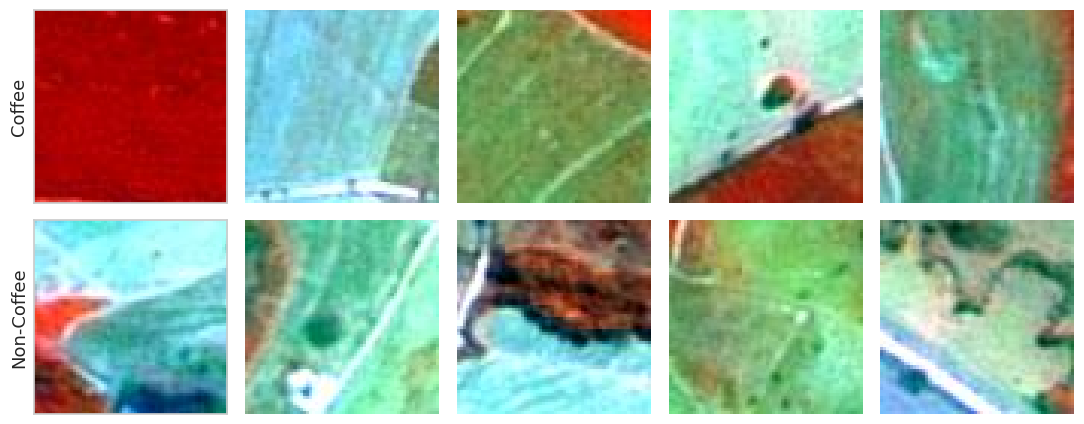

In [ ]:
import matplotlib.pyplot as plt, numpy as np
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
for r, (cls, lab) in enumerate([(1,"Coffee"), (0,"Non-Coffee")]):
    idxs = np.where(y == cls)[0][:5]
    for c, idx in enumerate(idxs):
        axes[r, c].imshow(X_img[idx]); axes[r, c].axis('off')
    axes[r, 0].set_ylabel(lab, fontsize=13, rotation=90); axes[r,0].axis('on')
    axes[r,0].set_xticks([]); axes[r,0].set_yticks([])
plt.tight_layout(); plt.savefig('dataset_samples.png', dpi=200, bbox_inches='tight'); plt.show()

In [ ]:
import pandas as pd
for name, f in [("RF","performances_ml"),("CNN","performances_cnn"),
                ("VGG16","performances_vgg16"),("Hybrid","performances_hybrid")]:
    d = pd.read_csv(f"/content/brazilian-coffee-scene-dataset-experiments/results/{f}.csv")
    print(f"{name:8s} acc={d.acc.mean():.4f}\u00b1{d.acc.std():.4f}  f1={d.f1s.mean():.4f}\u00b1{d.f1s.std():.4f}")

RF       acc=0.8834±0.0102  f1=0.8798±0.0111
CNN      acc=0.8435±0.0210  f1=0.8378±0.0291
VGG16    acc=0.8535±0.0112  f1=0.8530±0.0118
Hybrid   acc=0.8949±0.0092  f1=0.8943±0.0100


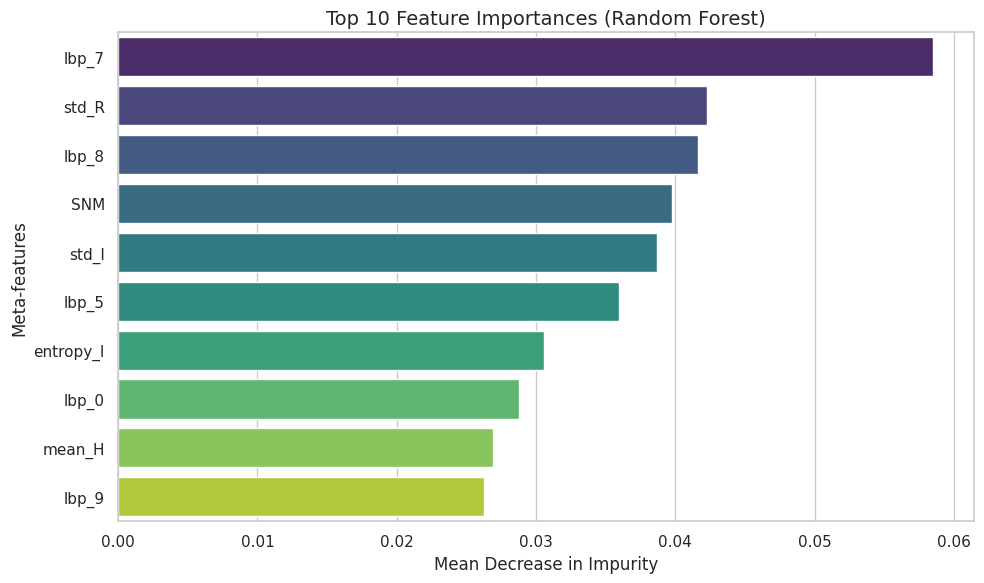

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Corrigir a divisão dos dados usando os nomes de variáveis corretos
# X_feat_all e y_all_img foram criados na célula 'bSpX3gJzzcfH'
X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    X_feat_all, y_all_img, test_size=0.3, random_state=29, stratify=y_all_img
)

# 2. Instanciar e treinar o modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=29, n_jobs=-1)
rf_model.fit(X_train_feat, y_train)

# 3. Obter as importâncias das características e os nomes das colunas
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10

# Obtendo os nomes das colunas do df_feat (removendo 'Name_file')
feature_names = df_feat.drop(columns=['Name_file']).columns.tolist()

# 4. Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], hue=np.array(feature_names)[indices], palette="viridis", legend=False)
plt.title("Top 10 Feature Importances (Random Forest)", fontsize=14)
plt.xlabel("Mean Decrease in Impurity", fontsize=12)
plt.ylabel("Meta-features", fontsize=12)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

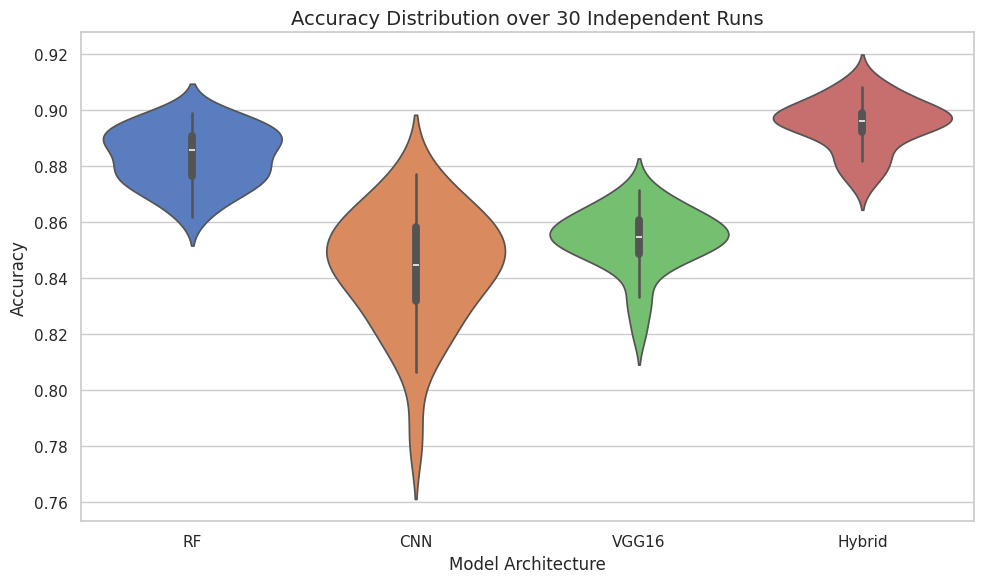

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Carregar e consolidar os resultados das 30 runs
results_path = '/content/brazilian-coffee-scene-dataset-experiments/results/'
files = {
    'RF': 'performances_ml.csv',
    'CNN': 'performances_cnn.csv',
    'VGG16': 'performances_vgg16.csv',
    'Hybrid': 'performances_hybrid.csv'
}

all_data = []
for model_name, file_name in files.items():
    path = os.path.join(results_path, file_name)
    if os.path.exists(path):
        df_temp = pd.read_csv(path)
        df_temp['Model'] = model_name
        # Garantir que a coluna de acurácia se chame 'Accuracy'
        df_temp = df_temp.rename(columns={'acc': 'Accuracy'})
        all_data.append(df_temp[['Model', 'Accuracy']])

df_results = pd.concat(all_data, ignore_index=True)

# 2. Gerar o gráfico de violino corrigido
plt.figure(figsize=(10, 6))
sns.violinplot(x="Model", y="Accuracy", data=df_results, inner="box", palette="muted", hue="Model", legend=False)
plt.title("Accuracy Distribution over 30 Independent Runs", fontsize=14)
plt.xlabel("Model Architecture", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.tight_layout()
plt.savefig("violinplot_english.png", dpi=300)
plt.show()